# Value at Risk (VaR) Model
## A Quantitative Risk Analysis of a 5-Stock Portfolio
### Cynthia Wanjiru | WashU MSQF 2026

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats


## Step 1: Download historical stock data
tickers = ( 'AAPL' , 'JPM' , 'XOM' , 'JNJ' , 'SPY' )
weights = ( 0.2, 0.2, 0.2, 0.2, 0.2)
start_date = '2020-01-01'
end_date = '2024-12-31'
data = yf.download(tickers, start=start_date, end=end_date)['Close']


In [3]:
tickers = ['AAPL', 'JPM', 'XOM', 'JNJ', 'SPY']
weights = [0.2, 0.2, 0.2, 0.2, 0.2]
start_date = '2020-01-01'
end_date = '2024-12-31'
data = yf.download(tickers, start=start_date, end=end_date)['Close']

[*********************100%***********************]  5 of 5 completed


In [4]:
returns =data.pct_change() .dropna()
returns.head()

Ticker,AAPL,JNJ,JPM,SPY,XOM
Date,,,,,
2020-01-03,-0.009722,-0.011578,-0.013197,-0.007572,-0.008040
2020-01-06,0.007968,-0.001247,-0.000795,0.003815,0.007678
2020-01-07,-0.004703,0.006107,-0.017001,-0.002812,-0.008184
2020-01-08,0.016086,-0.000137,0.007801,0.005329,-0.015080
2020-01-09,0.021241,0.002966,0.003651,0.006781,0.007656


In [5]:
portfolio_returns = returns.dot(weights)
print (len(portfolio_returns))

1256


In [6]:
## Step 2: Historical Simulation VaR
Confidence_level= 0.95
historical_VaR= np.percentile(portfolio_returns, (1-Confidence_level) * 100)
print (historical_VaR)


-0.0180343194954012


In [7]:
### Step 3: Parametric VaR
mean_return= portfolio_returns.mean()
std_return= portfolio_returns.std()
Parametric_VaR= mean_return - (stats.norm.ppf(Confidence_level) * std_return)
print (Parametric_VaR)

-0.0214303254823568


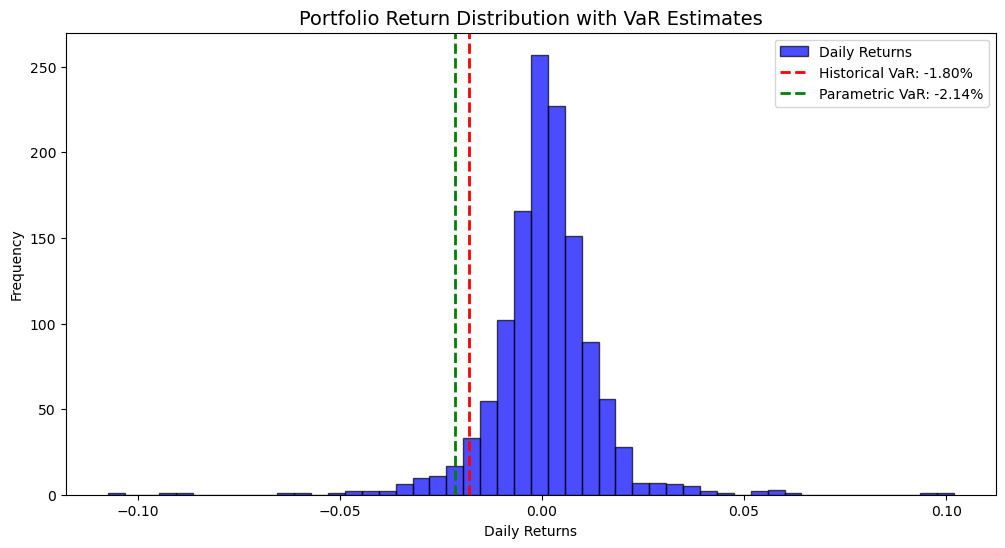

In [8]:
### Step 4: Visualization
plt.figure(figsize=(12, 6))
plt.hist(portfolio_returns, bins=50, alpha=0.7, color='blue', edgecolor='black', label='Daily Returns')
plt.axvline(historical_VaR, color='red', linestyle='--', linewidth=2, label=f'Historical VaR: {historical_VaR*100:.2f}%')
plt.axvline(Parametric_VaR, color='green', linestyle='--', linewidth=2, label=f'Parametric VaR: {Parametric_VaR*100:.2f}%')
plt.title('Portfolio Return Distribution with VaR Estimates', fontsize=14)
plt.xlabel('Daily Returns')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [9]:
# Final Comparison Summary
print("=" * 50)
print("PORTFOLIO VAR ANALYSIS - SUMMARY")
print("=" * 50)
print(f"Portfolio: AAPL, JNJ, JPM, SPY, XOM")
print(f"Equal Weights: 20% each")
print(f"Time Period: 2020 - 2024")
print(f"Confidence Level: 95%")
print(f"Trading Days Analyzed: {len(portfolio_returns)}")
print("-" * 50)
print(f"Historical Simulation VaR: {historical_VaR*100:.2f}%")
print(f"Parametric VaR:            {Parametric_VaR*100:.2f}%")
print("-" * 50)
print(f"Difference: {abs(Parametric_VaR - historical_VaR)*100:.2f}%")
print("=" * 50)

PORTFOLIO VAR ANALYSIS - SUMMARY
Portfolio: AAPL, JNJ, JPM, SPY, XOM
Equal Weights: 20% each
Time Period: 2020 - 2024
Confidence Level: 95%
Trading Days Analyzed: 1256
--------------------------------------------------
Historical Simulation VaR: -1.80%
Parametric VaR:            -2.14%
--------------------------------------------------
Difference: 0.34%
